In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
I_1 = 0.1 # [kg.m^2]
I_2 = 5 # [kg.m^2]
c = 25 # [N.m/rad]

In [ ]:
class TwoDOFTorsionalSystem:
    
    # Constructor to initialize the system parameters
    def __init__(self, I_1=0, I_2=0, c=0):
        self.I_1 = I_1
        self.I_2 = I_2
        self.c = c
        if self.I_1 > 0 and self.I_2 > 0 and self.c > 0:
            self.omega_n = self.calculate_natural_frequency()
        else:
            self.omega_n = None
    
    # Method to calculate the natural frequency of the system: Out-of-phase vibration mode
    def calculate_natural_frequency(self):
        return np.sqrt(self.c * (self.I_1 + self.I_2) / (self.I_1 * self.I_2))
    
    # Method to simulate the time response of the system: Free Vibrations
    def simulate_time_response(self, initial_angle=np.array([0.0, 0.0]), initial_velocity=np.array([0.0, 0.0]), time_span=10):
        if self.omega_n is None:
            raise ValueError("Natural frequency is not defined. Please set inertias and stiffness.")
        self.A = np.array([
            [1, 1, 0, 0, 0, 0, 0, 0],
            [0, 0, 1, self.omega_n, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 1, self.omega_n],
            [1, 0, 0, 0, -1, 0, 0, 0],
            [0, self.I_1/self.I_2, 0, 0, 0, 1, 0, 0],
            [0, 0, 1, 0, 0, 0, -1, 0],
            [0, 0, 0, self.I_1/self.I_2, 0, 0, 0, 1]
        ])
        self.b = np.array([initial_angle[0], initial_velocity[0], initial_angle[1], initial_velocity[1], 0, 0, 0, 0])
        A_1_1, A_1_2, B_1_1, B_1_2, A_2_1, A_2_2, B_2_1, B_2_2 = np.linalg.solve(self.A, self.b)
        t = np.linspace(0, time_span, 1000)
        theta_1 = A_1_1 + B_1_1 * t + A_1_2 * np.cos(self.omega_n * t) + B_1_2 * np.sin(self.omega_n * t)
        theta_2 = A_2_1 + B_2_1 * t + A_2_2 * np.cos(self.omega_n * t) + B_2_2 * np.sin(self.omega_n * t)
        return t, theta_1, theta_2

In [ ]:
# Define an instance of the model
S = TwoDOFTorsionalSystem(I_1=I_1, I_2=I_2, c=c)

np.float64(15.968719422671311)

In [ ]:
# Define Initial Conditions
theta_0 = [1, -0.1] # Initial angular position
theta_dot_0 = [-2, 0.1] # Initial angular velocity
# Calculate solution
t, theta_1, theta_2 = S.simulate_time_response(initial_angle=theta_0, initial_velocity=theta_dot_0)

Text(-0.5, 40, '$\\mathbf{\\theta_1(0) = 1 [rad]}$\n$\\mathbf{\\dot{\\theta}_1(0) = -2 [rad/s]}$\n$\\mathbf{\\theta_2(0) = -0.1 [rad]}$\n$\\mathbf{\\dot{\\theta}_2(0) = 0.1 [rad/s]}$')

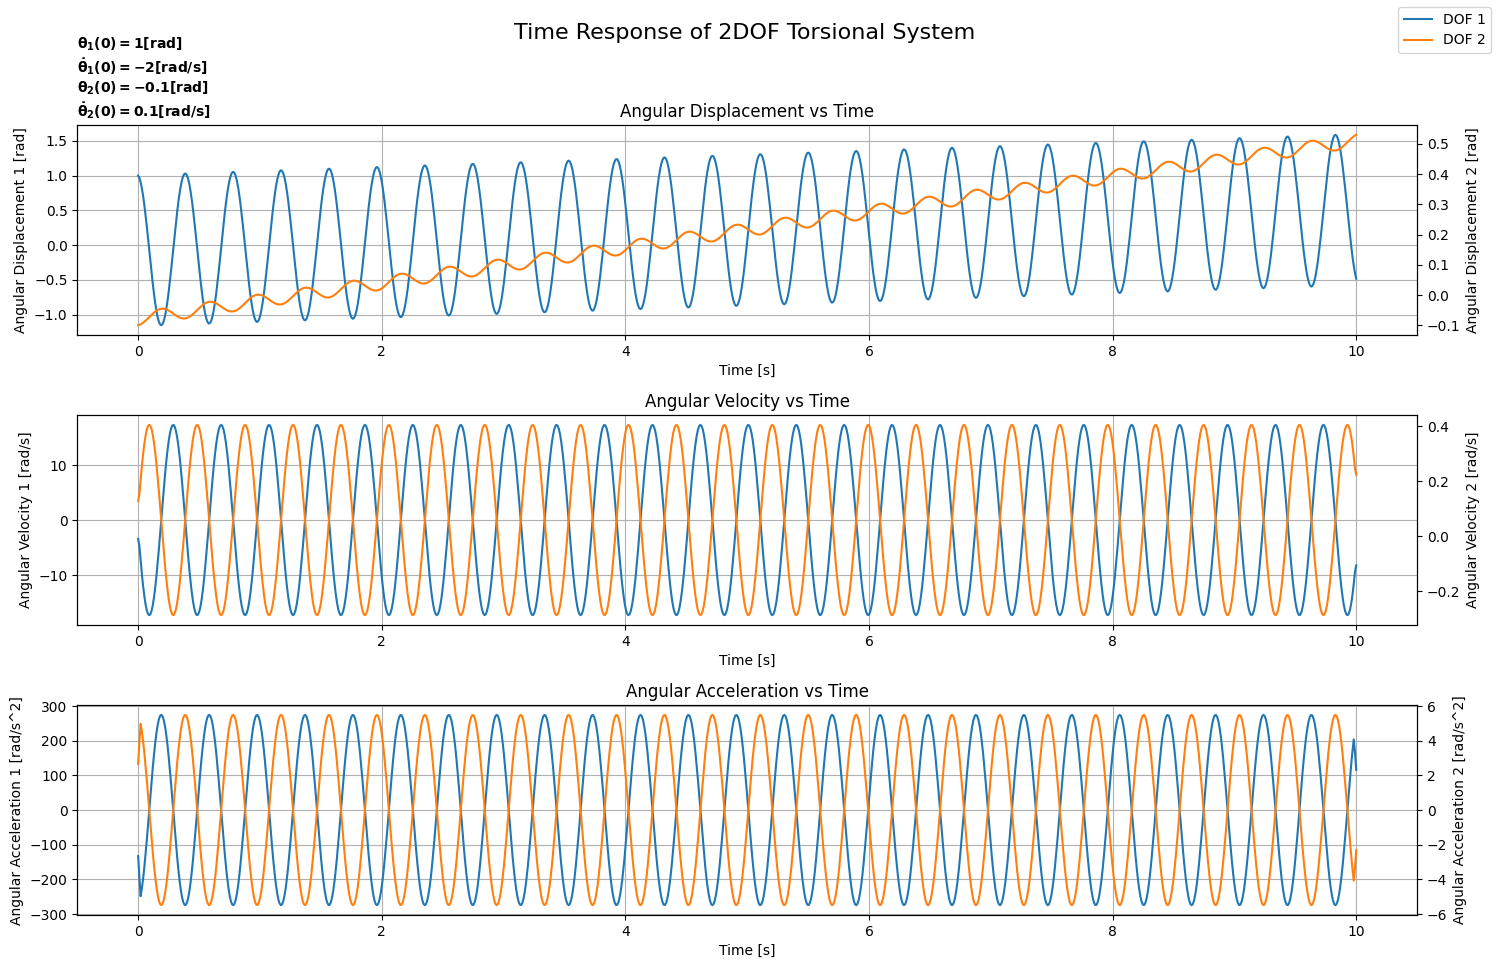

In [74]:
# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(15, 10))
fig.suptitle('Time Response of 2DOF Torsional System', fontsize=16)
# Angular Displacement vs Time
ax2 = axes[0].twinx()
axes[0].plot(t, theta_1, label='DOF 1')
ax2.plot(t, theta_2, label='DOF 2', color='#ff7f0e')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement 1 [rad]')
ax2.set_ylabel('Angular Displacement 2 [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity_1 = np.gradient(theta_1, t, axis=0)
angular_velocity_2 = np.gradient(theta_2, t, axis=0)

ax2 = axes[1].twinx()
axes[1].plot(t, angular_velocity_1)
ax2.plot(t, angular_velocity_2, color='#ff7f0e')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity 1 [rad/s]')
ax2.set_ylabel('Angular Velocity 2 [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration_1 = np.gradient(angular_velocity_1, t, axis=0)
angular_acceleration_2 = np.gradient(angular_velocity_2, t, axis=0)

ax2 = axes[2].twinx()
axes[2].plot(t, angular_acceleration_1)
ax2.plot(t, angular_acceleration_2, color='#ff7f0e')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration 1 [rad/s^2]')
ax2.set_ylabel('Angular Acceleration 2 [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)

fig.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.text(-0.5, 40, r"$\mathbf{\theta_1(0) = 1 [rad]}$" + "\n" + r"$\mathbf{\dot{\theta}_1(0) = -2 [rad/s]}$" + "\n" + 
         r"$\mathbf{\theta_2(0) = -0.1 [rad]}$" + "\n" + r"$\mathbf{\dot{\theta}_2(0) = 0.1 [rad/s]}$")